In [7]:
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import jax
import jax.numpy as jnp
from scipy.optimize import minimize
from scipy.sparse.linalg import LinearOperator, eigsh

jax.config.update("jax_enable_x64", True)
Array = jnp.ndarray

In [8]:
@dataclass
class PDESolver:
    n_cells: int = 32
    n_blocks: int = 8
    length: float = 1.0
    rhs_scale: float = 10.0
    dtype: jnp.dtype = jnp.float64

    def __post_init__(self):
        if self.n_cells % self.n_blocks != 0:
            raise ValueError("n_cells must be divisible by n_blocks")

        self.block_size = self.n_cells // self.n_blocks
        self.n_nodes_1d = self.n_cells + 1
        self.N = self.n_nodes_1d**2
        self.theta_dim = self.n_blocks**2
        self.h = self.length / self.n_cells

        self._A_loc = np.array(
            [
                [2.0 / 3.0, -1.0 / 6.0, -1.0 / 3.0, -1.0 / 6.0],
                [-1.0 / 6.0, 2.0 / 3.0, -1.0 / 6.0, -1.0 / 3.0],
                [-1.0 / 3.0, -1.0 / 6.0, 2.0 / 3.0, -1.0 / 6.0],
                [-1.0 / 6.0, -1.0 / 3.0, -1.0 / 6.0, 2.0 / 3.0],
            ],
            dtype=np.float64,
        )

        self._build_indices()
        self._build_rhs_and_measurements()
        self._compile()

    @staticmethod
    def _ij_to_dof(i: int, j: int, n_nodes_1d: int) -> int:
        return n_nodes_1d * j + i

    def _build_indices(self):
        boundary = []
        for i in range(self.n_nodes_1d):
            boundary.append(self._ij_to_dof(i, 0, self.n_nodes_1d))
            boundary.append(self._ij_to_dof(i, self.n_nodes_1d - 1, self.n_nodes_1d))
        for j in range(1, self.n_nodes_1d - 1):
            boundary.append(self._ij_to_dof(0, j, self.n_nodes_1d))
            boundary.append(self._ij_to_dof(self.n_nodes_1d - 1, j, self.n_nodes_1d))
        boundary = np.array(sorted(set(boundary)), dtype=np.int32)

        row_entries: List[int] = []
        col_entries: List[int] = []
        theta_entry_ids: List[int] = []
        local_coeffs: List[float] = []

        for i in range(self.n_cells):
            for j in range(self.n_cells):
                theta_idx = (i // self.block_size) + (j // self.block_size) * self.n_blocks
                dof = [
                    self._ij_to_dof(i, j, self.n_nodes_1d),
                    self._ij_to_dof(i, j + 1, self.n_nodes_1d),
                    self._ij_to_dof(i + 1, j + 1, self.n_nodes_1d),
                    self._ij_to_dof(i + 1, j, self.n_nodes_1d),
                ]
                for p in range(4):
                    for q in range(4):
                        row_entries.append(dof[p])
                        col_entries.append(dof[q])
                        theta_entry_ids.append(theta_idx)
                        local_coeffs.append(float(self._A_loc[p, q]))

        self.boundaries = jnp.asarray(boundary, dtype=jnp.int32)
        self.row_entries = jnp.asarray(np.array(row_entries, dtype=np.int32), dtype=jnp.int32)
        self.col_entries = jnp.asarray(np.array(col_entries, dtype=np.int32), dtype=jnp.int32)
        self.theta_entry_ids = jnp.asarray(np.array(theta_entry_ids, dtype=np.int32), dtype=jnp.int32)
        self.local_coeffs = jnp.asarray(np.array(local_coeffs, dtype=np.float64), dtype=self.dtype)

    def _build_rhs_and_measurements(self):
        b = np.ones((self.N,), dtype=np.float64) * self.rhs_scale * (self.h**2)
        b[np.asarray(self.boundaries)] = 0.0
        self.b = jnp.asarray(b, dtype=self.dtype)

        xs = np.arange(1.0 / 14.0, 13.0 / 14.0, 1.0 / 14.0)

        def heaviside(x):
            return 0.0 if x < 0 else 1.0

        def S(x, y):
            h = self.h
            return heaviside(x) * heaviside(y) * (1 - heaviside(x - h)) * (1 - heaviside(y - h))

        def phi(x, y):
            h = self.h
            return (
                (x + h) * (y + h) * S(x + h, y + h)
                + (h - x) * (h - y) * S(x, y)
                + (x + h) * (h - y) * S(x + h, y)
                + (h - x) * (y + h) * S(x, y + h)
            ) / (h**2)

        M = np.zeros((13, 13, self.N), dtype=np.float64)
        for k in range(self.N):
            i0 = k % self.n_nodes_1d
            j0 = k // self.n_nodes_1d
            for i in range(13):
                for j in range(13):
                    M[i, j, k] = phi(xs[i] - self.h * i0, xs[j] - self.h * j0)
        self.M = jnp.asarray(M.reshape((13**2, self.N)), dtype=self.dtype)

    def _compile(self):
        boundaries = self.boundaries
        row_entries = self.row_entries
        col_entries = self.col_entries
        theta_entry_ids = self.theta_entry_ids
        local_coeffs = self.local_coeffs
        b = self.b

        @jax.jit
        def _solve_u(theta: Array) -> Array:
            vals = theta[theta_entry_ids] * local_coeffs
            A = jnp.zeros((self.N, self.N), dtype=theta.dtype)
            A = A.at[(row_entries, col_entries)].add(vals)
            A = A.at[boundaries, :].set(0.0)
            A = A.at[:, boundaries].set(0.0)
            A = A.at[(boundaries, boundaries)].set(1.0)
            return jnp.linalg.solve(A, b)

        @jax.jit
        def _predict_z(theta: Array) -> Array:
            u = _solve_u(theta)
            return self.M @ u

        self._solve_u = _solve_u
        self._predict_z = _predict_z

    def solve_u(self, theta: Array) -> Array:
        return self._solve_u(jnp.asarray(theta, dtype=self.dtype))

    def predict_z(self, theta: Array) -> Array:
        return self._predict_z(jnp.asarray(theta, dtype=self.dtype))

    def predict_z_from_log_theta(self, log_theta: Array) -> Array:
        return self.predict_z(jnp.exp(jnp.asarray(log_theta, dtype=self.dtype)))

In [9]:
@dataclass
class PosteriorModel:
    solver: PDESolver
    z_hat: Optional[Array] = None
    sigma_like: float = 0.05
    sigma_prior: float = 2.0
    prior_mean: float = 0.0

    @staticmethod
    def _load_default_z_hat() -> np.ndarray:
        return np.array(
            [
                0.06076511762259369, 0.09601910120848481, 0.1238852517838584, 0.1495184117375201, 0.1841596127549784, 0.2174525028261122, 0.2250996160898698, 0.2197954769002993, 0.2074695698370926, 0.1889996477663016, 0.1632722532153726, 0.1276782480038186, 0.07711845915789312,
                0.09601910120848552, 0.2000589533367983, 0.3385592591951766, 0.3934300024647806, 0.4040223892461541, 0.4122329537843092, 0.4100480091545554, 0.3949151637189968, 0.3697873264791232, 0.33401826235924, 0.2850397806663382, 0.2184260032478671, 0.1271121156350957,
                0.1238852517838611, 0.3385592591951819, 0.7119285162766475, 0.8175712861756428, 0.6836254116578105, 0.5779452419831157, 0.5555615956136897, 0.5285181561736719, 0.491439702849224, 0.4409367494853282, 0.3730060082060772, 0.2821694983395214, 0.1610176733857739,
                0.1495184117375257, 0.3934300024647929, 0.8175712861756562, 0.9439154625527653, 0.8015904115095128, 0.6859683749254024, 0.6561235366960599, 0.6213197201867315, 0.5753611315000049, 0.5140091754526823, 0.4325325506354165, 0.3248315148915482, 0.1834600412730086,
                0.1841596127549917, 0.4040223892461832, 0.6836254116578439, 0.8015904115095396, 0.7870119561144977, 0.7373108331395808, 0.7116558878070463, 0.6745179049094283, 0.6235300574156917, 0.5559332704045935, 0.4670304994474178, 0.3499809143811, 0.19688263746294,
                0.2174525028261253, 0.4122329537843404, 0.5779452419831566, 0.6859683749254372, 0.7373108331396063, 0.7458811983178246, 0.7278968022406559, 0.690479353535775, 0.6369176452710288, 0.5677443693743215, 0.4784738764865867, 0.3602190632823262, 0.2031792054737325,
                0.2250996160898818, 0.4100480091545787, 0.5555615956137137, 0.6561235366960938, 0.7116558878070715, 0.727896802240657, 0.7121928678670187, 0.6712187391428729, 0.6139157775591492, 0.547825166529538, 0.4677122687599031, 0.3587654911000848, 0.2050734291675918,
                0.2197954769003094, 0.3949151637190157, 0.5285181561736911, 0.6213197201867471, 0.6745179049094407, 0.690479353535786, 0.6712187391428787, 0.6178408289359514, 0.5453605027237883, 0.489575966490909, 0.4341716881061278, 0.3534389974779456, 0.2083227496961347,
                0.207469569837099, 0.3697873264791366, 0.4914397028492412, 0.5753611315000203, 0.6235300574157017, 0.6369176452710497, 0.6139157775591579, 0.5453605027237935, 0.4336604929612851, 0.4109641743019312, 0.3881864790111245, 0.3642640090182592, 0.2179599909280145,
                0.1889996477663011, 0.3340182623592461, 0.4409367494853381, 0.5140091754526943, 0.555933270404597, 0.5677443693743304, 0.5478251665295453, 0.4895759664908982, 0.4109641743019171, 0.395727260284338, 0.3778949322004734, 0.3596268271857124, 0.2191250268948948,
                0.1632722532153683, 0.2850397806663325, 0.373006008206081, 0.4325325506354207, 0.4670304994474315, 0.4784738764866023, 0.4677122687599041, 0.4341716881061055, 0.388186479011099, 0.3778949322004602, 0.3633362567187364, 0.3464457261905399, 0.2096362321365655,
                0.1276782480038148, 0.2184260032478634, 0.2821694983395252, 0.3248315148915535, 0.3499809143811097, 0.3602190632823333, 0.3587654911000799, 0.3534389974779268, 0.3642640090182283, 0.35962682718569, 0.3464457261905295, 0.3260728953424643, 0.180670595355394,
                0.07711845915789244, 0.1271121156350963, 0.1610176733857757, 0.1834600412730144, 0.1968826374629443, 0.2031792054737354, 0.2050734291675885, 0.2083227496961245, 0.2179599909279998, 0.2191250268948822, 0.2096362321365551, 0.1806705953553887, 0.1067965550010013,
            ],
            dtype=float,
        )

    def __post_init__(self):
        if self.z_hat is None:
            self.z_hat = self._load_default_z_hat()
        self.z_hat = jnp.asarray(self.z_hat, dtype=self.solver.dtype)

    def log_likelihood(self, log_theta: Array) -> Array:
        z_pred = self.solver.predict_z_from_log_theta(log_theta)
        misfit = z_pred - self.z_hat
        return -jnp.dot(misfit, misfit) / (2.0 * self.sigma_like**2)

    def log_prior(self, log_theta: Array) -> Array:
        diff = log_theta - self.prior_mean
        return -jnp.dot(diff, diff) / (2.0 * self.sigma_prior**2)

    def log_posterior(self, log_theta: Array) -> Array:
        return self.log_likelihood(log_theta) + self.log_prior(log_theta)

    def neg_log_posterior(self, log_theta: Array) -> Array:
        return -self.log_posterior(log_theta)

    def map_estimate(self, x0: np.ndarray, method: str = "L-BFGS-B") -> Dict[str, object]:
        neg_logpost_jit = jax.jit(lambda x: self.neg_log_posterior(x))
        grad_fun = jax.jit(jax.grad(lambda x: self.neg_log_posterior(x)))

        def fun(x: np.ndarray) -> float:
            return float(jax.device_get(neg_logpost_jit(jnp.asarray(x, dtype=self.solver.dtype))))

        def jac(x: np.ndarray) -> np.ndarray:
            g = grad_fun(jnp.asarray(x, dtype=self.solver.dtype))
            return np.asarray(jax.device_get(g), dtype=np.float64)

        res = minimize(fun=fun, x0=np.asarray(x0, dtype=np.float64), jac=jac, method=method)
        x_map = jnp.asarray(res.x, dtype=self.solver.dtype)
        return {
            "log_theta_map": x_map,
            "theta_map": jnp.exp(x_map),
            "log_post_map": self.log_posterior(x_map),
            "success": bool(res.success),
            "message": str(res.message),
            "nit": int(getattr(res, "nit", -1)),
        }

In [10]:
@dataclass
class InstantonResult:
    log_theta: Array
    qoi: float
    rate: float
    lam: float
    mu: float
    success: bool
    message: str
    history: List[Dict[str, float]]


def _normalize(v: Array, eps: float = 1e-14) -> Array:
    return v / jnp.maximum(jnp.linalg.norm(v), eps)


def _project_perp_unit(e: Array, x: Array) -> Array:
    return x - e * jnp.vdot(e, x)


@dataclass
class Instanton:
    posterior: PosteriorModel
    qoi_fn: Callable[[Array], Array]

    def __post_init__(self):
        self.rate_fn = jax.jit(lambda x: -self.posterior.log_posterior(x))
        self.grad_rate = jax.jit(jax.grad(self.rate_fn))
        self.grad_qoi = jax.jit(jax.grad(self.qoi_fn))
        self.rate_and_grad = jax.jit(jax.value_and_grad(self.rate_fn))
        self.qoi_and_grad = jax.jit(jax.value_and_grad(self.qoi_fn))

    def optimize(
        self,
        lbda: float,
        targetObservable: float = 1.0,
        mu: float = 0.0,
        initialM: Optional[np.ndarray] = None,
        maxiter: int = 200,
        method: str = "L-BFGS-B",
    ) -> Tuple[float, float, float, Array]:
        m0 = np.asarray(initialM, dtype=np.float64) if initialM is not None else np.zeros((self.posterior.solver.theta_dim,), dtype=np.float64)

        def objective(m_np: np.ndarray):
            m = jnp.asarray(m_np, dtype=self.posterior.solver.dtype)
            rate, grad_rate = self.rate_and_grad(m)
            q, grad_q = self.qoi_and_grad(m)
            c = q - targetObservable
            val = rate - lbda * c + 0.5 * mu * c * c
            grad = grad_rate + (-lbda + mu * c) * grad_q
            return float(jax.device_get(val)), np.asarray(jax.device_get(grad), dtype=np.float64)

        def fun(x: np.ndarray) -> float:
            v, _ = objective(x)
            return v

        def jac(x: np.ndarray) -> np.ndarray:
            _, g = objective(x)
            return g

        res = minimize(fun=fun, x0=m0, jac=jac, method=method, options={"maxiter": maxiter})
        m = jnp.asarray(res.x, dtype=self.posterior.solver.dtype)
        obsValue = float(jax.device_get(self.qoi_fn(m)))
        action = float(jax.device_get(self.rate_fn(m)))
        return obsValue, action, float(lbda), m

    def searchInstantonViaAugmented(
        self,
        targetObservable: float,
        muMin: float = np.log10(5.0),
        muMax: float = np.log10(100.0),
        nMu: int = 8,
        initLbda: float = 1.0,
        initialM: Optional[np.ndarray] = None,
        tol_constraint: float = 1e-6,
    ) -> InstantonResult:
        muList = np.logspace(muMin, muMax, nMu)
        lbda = float(initLbda)
        m = initialM
        history: List[Dict[str, float]] = []

        for mu in muList:
            obsValue, action, _, m_j = self.optimize(
                lbda,
                targetObservable=targetObservable,
                mu=float(mu),
                initialM=m,
            )
            c = targetObservable - obsValue
            lbda = float(mu) * c + lbda
            m = np.asarray(jax.device_get(m_j), dtype=np.float64)
            history.append({"mu": float(mu), "lambda": float(lbda), "qoi": float(obsValue), "rate": float(action), "constraint": float(c)})

        m_final = jnp.asarray(m, dtype=self.posterior.solver.dtype)
        q_final = float(jax.device_get(self.qoi_fn(m_final)))
        rate_final = float(jax.device_get(self.rate_fn(m_final)))
        msg = "constraint met" if abs(q_final - targetObservable) <= tol_constraint else "constraint tolerance not met"

        return InstantonResult(
            log_theta=m_final,
            qoi=q_final,
            rate=rate_final,
            lam=float(lbda),
            mu=float(muList[-1]),
            success=bool(abs(q_final - targetObservable) <= max(tol_constraint, 1e-4)),
            message=msg,
            history=history,
        )

    def exceedance_probability_estimate(
        self,
        result: InstantonResult,
        eps: float = 1.0,
        z_hat: float = 1.0,
        det_tol: float = 1e-8,
        eig_floor: float = 1e-10,
        sigma_prior: Optional[float] = 2,
        n_eigs: Optional[int] = None,
        projectMPerp: bool = True,
    ) -> Dict[str, float]:
        m = jnp.asarray(result.log_theta, dtype=self.posterior.solver.dtype)
        dim = int(m.size)
        C0_sqrt = sigma_prior*jnp.eye(dim, dtype=m.dtype)
        #C0_inv_sqrt = 1/sigma_prior*jnp.eye(dim, dtype=m.dtype)

        dJ = self.grad_rate(m)
        lmda_kkt = jnp.asarray(result.lam, dtype=m.dtype)
        J_inst = self.rate_fn(m)

        ebar = _normalize(C0_sqrt @ dJ)

        @jax.jit
        def hessvec_J(v: Array) -> Array:
            return jax.jvp(self.grad_rate, (m,), (v,))[1]

        @jax.jit
        def hessvec_q(v: Array) -> Array:
            return jax.jvp(self.grad_qoi, (m,), (v,))[1]

        @jax.jit
        def L_matvec(v: Array) -> Array:
            vin = _project_perp_unit(ebar, v) if projectMPerp else v
            y = C0_sqrt @ vin
            Hy = hessvec_J(y) - lmda_kkt * hessvec_q(y)
            inner = vin - (C0_sqrt @ Hy)
            ldt = _project_perp_unit(ebar, inner) if projectMPerp else inner
            return ldt

        def matvec_np(x_np: np.ndarray) -> np.ndarray:
            y = L_matvec(jnp.asarray(x_np, dtype=m.dtype))
            return np.asarray(jax.device_get(y), dtype=np.float64)

        op = LinearOperator((dim, dim), matvec=matvec_np, dtype=np.float64)
        k = int((dim - 1) if n_eigs is None else min(max(1, n_eigs), dim - 1))
        evals = eigsh(op, k=k, which="LM", tol=det_tol, return_eigenvectors=False)
        evals = np.real(evals)
        logdet = float(np.sum(np.log(np.clip(np.abs(1.0 - evals), eig_floor, None))))

        base_factor = (1.0 / z_hat) * jnp.sqrt(eps / (2.0 * jnp.pi)) * jnp.exp(-J_inst / eps)
        #dJ_norm = jnp.linalg.norm(dJ) + 1e-14
        #term1 = jnp.vdot(dJ, C0_inv_sqrt @ dJ) / (dJ_norm**3)
        term1 = jnp.linalg.norm(C0_sqrt @ dJ)
        det_term = jnp.exp(-0.5 * logdet)
        exceedance_prob = (2.0 * jnp.pi * eps* sigma_prior**2) ** (dim / 2.0) * base_factor / term1 * det_term
        density_estimate = jnp.abs(lmda_kkt / eps) * exceedance_prob

        return {
            "qoi": float(jax.device_get(self.qoi_fn(m))),
            "rate": float(jax.device_get(J_inst)),
            "lambda": float(jax.device_get(lmda_kkt)),
            "logdet": float(logdet),
            "exceedance_prob": float(jax.device_get(exceedance_prob)),
            "density_estimate": float(jax.device_get(density_estimate)),
            "det_k": int(k),
            "evals": evals.tolist(),
        }


def qoi_block(log_theta: Array, ix: int = 0, iy: int = 1, n_blocks: int = 8) -> Array:
    blocks = jnp.reshape(log_theta, (n_blocks, n_blocks)).T
    return blocks[ix, iy]

In [11]:
def _block_pairs_to_flat_indices(pairs: List[Tuple[int, int]], n_blocks: int) -> np.ndarray:
    indices = []
    for ix, iy in pairs:
        if ix < 0 or iy < 0 or ix >= n_blocks or iy >= n_blocks:
            raise ValueError(f"block index out of range: {(ix, iy)} for n_blocks={n_blocks}")
        indices.append(ix + iy * n_blocks)
    if len(indices) == 0:
        raise ValueError("selected_pairs must contain at least one (ix, iy) pair")
    return np.asarray(indices, dtype=np.int32)


def qoi_selected_mean(log_theta: Array, selected_indices: Array) -> Array:
    return jnp.mean(jnp.asarray(log_theta)[jnp.asarray(selected_indices, dtype=jnp.int32)])

MAP success: True
MAP message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
MAP log posterior: -4.815274842259011

Instanton success: False
Instanton qoi: -0.5658191851376693
Instanton rate: 5.465139783169581
Instanton lambda: 6.741549121609739

Laplace evidence at MAP (JVP/HVP-based)
  d             = 64
  logf(MAP)     = -4.815274842259011
  slogdet(H): sign= 1.0 logdet= 57.6976082471206
  jitter_used   = 0.0
  logZhat_laplace = 25.147987159279744

Derived Z_hat (Laplace)
  eps_for_Zhat      = 1.0
  logZhat_laplace   = 25.147987159279744
  Z_hat_laplace     = 83489537310.34067

QoI histogram range for density overlay
  selected_pairs = [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1)]
  selected_indices = [9, 10, 11, 12, 13, 14]
  lower           = -1.6572221843630748
  upper         = 0.8082382106078972
  z_grid        = 10
  n_samples     = 80000


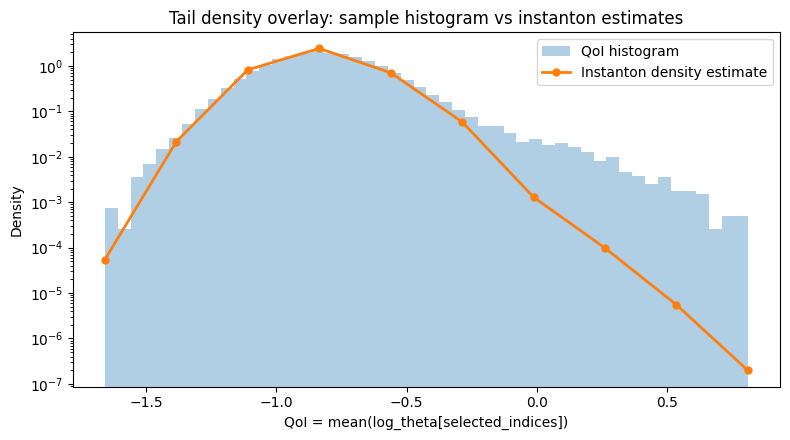


Pointwise estimates on z-grid
  z=-1.657222 | exceedance=2.962e-06 | density=5.474e-05 | lambda=-18.480053
  z=-1.383282 | exceedance=1.902e-03 | density=2.169e-02 | lambda=-11.403547
  z=-1.109342 | exceedance=1.169e-01 | density=8.239e-01 | lambda=-7.046677
  z=-0.835402 | exceedance=1.269e+00 | density=2.438e+00 | lambda=-1.920557
  z=-0.561462 | exceedance=1.040e-01 | density=7.112e-01 | lambda=6.838126
  z=-0.287522 | exceedance=4.029e-03 | density=5.880e-02 | lambda=14.594914
  z=-0.013582 | exceedance=1.553e-04 | density=1.298e-03 | lambda=8.357671
  z=0.260358 | exceedance=1.063e-05 | density=9.814e-05 | lambda=9.228682
  z=0.534298 | exceedance=4.993e-07 | density=5.529e-06 | lambda=11.073905
  z=0.808238 | exceedance=1.506e-08 | density=1.975e-07 | lambda=13.112796


In [12]:
# --- demo ---
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Build solver
solver = PDESolver(n_cells=32, n_blocks=8)

# Choose the QoI locations as block-coordinate pairs (zero-based)
selected_pairs = [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1)]
#selected_pairs = [(5, 5), (6, 5), (5, 6), (6, 6), (7, 5), (7, 6), (5, 7), (6, 7), (7, 7)]
selected_indices = _block_pairs_to_flat_indices(selected_pairs, solver.n_blocks)

# 2) Posterior + MAP
posterior = PosteriorModel(solver=solver, z_hat=None, sigma_like=0.05, sigma_prior=2.0)
x0 = np.zeros((solver.theta_dim,), dtype=np.float64)
map_out = posterior.map_estimate(x0=x0)
log_theta_map = map_out["log_theta_map"]

print("MAP success:", map_out["success"])
print("MAP message:", map_out["message"])
print("MAP log posterior:", float(jax.device_get(map_out["log_post_map"])))

# 3) Instanton object + baseline instanton
q_fn = lambda lt: qoi_selected_mean(lt, selected_indices)
instanton = Instanton(posterior=posterior, qoi_fn=q_fn)

q_map = float(jax.device_get(q_fn(log_theta_map)))
z_target = q_map + 0.2

inst_res = instanton.searchInstantonViaAugmented(
    targetObservable=float(z_target),
    muMin=np.log10(1.0),
    muMax=np.log10(1_000.0),
    nMu=4,
    initLbda=0.0,
    initialM=np.asarray(jax.device_get(log_theta_map)),
)

print("\nInstanton success:", inst_res.success)
print("Instanton qoi:", inst_res.qoi)
print("Instanton rate:", inst_res.rate)
print("Instanton lambda:", inst_res.lam)

# 4) Laplace approximation at MAP: evidence and derived Z_hat
log_posterior_log_theta = lambda x: posterior.log_posterior(x)

x_map = jnp.asarray(log_theta_map)
d = int(x_map.size)
eps_for_Zhat = 1.0

logf_map = log_posterior_log_theta(x_map)

def J(x):
    return -log_posterior_log_theta(x)

gradJ = jax.grad(J)

@jax.jit
def hvp(v):
    return jax.jvp(gradJ, (x_map,), (v,))[1]

cols = []
eye_dtype = x_map.dtype
for i in range(d):
    e = jnp.zeros((d,), dtype=eye_dtype).at[i].set(1.0)
    col = hvp(e)
    cols.append(np.asarray(jax.device_get(col), dtype=float))
H_np = np.column_stack(cols)
H_np = 0.5 * (H_np + H_np.T)

sign, logdetH = np.linalg.slogdet(H_np)
jitter_used = 0.0
if (not np.isfinite(logdetH)) or (sign <= 0):
    for jit in [1e-10, 1e-8, 1e-6, 1e-4, 1e-2]:
        sign, logdetH = np.linalg.slogdet(H_np + jit * np.eye(d))
        if np.isfinite(logdetH) and (sign > 0):
            jitter_used = float(jit)
            break

if sign <= 0 or (not np.isfinite(logdetH)):
    print("WARNING: Hessian not SPD / slogdet invalid; Laplace evidence may be invalid.")
    print("  sign=", sign, "logdetH=", logdetH, "jitter_used=", jitter_used)

logZhat_laplace = float(jax.device_get(logf_map)) + 0.5 * d * np.log(2.0 * np.pi) - 0.5 * float(logdetH)
Z_hat_laplace = float(np.exp(logZhat_laplace))

print("\nLaplace evidence at MAP (JVP/HVP-based)")
print("  d             =", d)
print("  logf(MAP)     =", float(jax.device_get(logf_map)))
print("  slogdet(H): sign=", float(sign), "logdet=", float(logdetH))
print("  jitter_used   =", float(jitter_used))
print("  logZhat_laplace =", float(logZhat_laplace))

print("\nDerived Z_hat (Laplace)")
print("  eps_for_Zhat      =", float(eps_for_Zhat))
print("  logZhat_laplace   =", float(logZhat_laplace))
print("  Z_hat_laplace     =", float(Z_hat_laplace))

# 5) Sample histogram at selected QoI locations in log-theta coordinates
data_dir = Path(".")
sample_files = sorted(data_dir.glob("samples-*.txt"))

qoi_samples = []
for path in sample_files:
    with path.open("r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 66:
                continue
            theta = np.array([float(v) for v in parts[2:]], dtype=np.float64)
            if np.any(theta <= 0.0):
                continue
            log_theta = np.log(theta)
            qoi_samples.append(np.mean(log_theta[selected_indices]))

qoi_samples = np.asarray(qoi_samples, dtype=np.float64)
if qoi_samples.size == 0:
    raise RuntimeError("No valid samples parsed for QoI histogram.")

upper = float(np.max(qoi_samples))
lower = float(np.min(qoi_samples))
z_grid = np.linspace(lower, upper, 10)

print("\nQoI histogram range for density overlay")
print("  selected_pairs =", selected_pairs)
print("  selected_indices =", selected_indices.tolist())
print("  lower           =", lower)
print("  upper         =", upper)
print("  z_grid        =", len(z_grid))
print("  n_samples     =", qoi_samples.size)

# 6) Overlay a few instanton-based density estimates on histogram
density_grid = []
exceedance_grid = []
lambda_grid = []

m_init = np.asarray(jax.device_get(log_theta_map), dtype=np.float64)
lam_init = float(inst_res.lam)

for z_val in z_grid:
    res_z = instanton.searchInstantonViaAugmented(
        targetObservable=float(z_val),
        muMin=np.log10(1.0),
        muMax=np.log10(1_000.0),
        nMu=4,
        initLbda=float(lam_init),
        initialM=m_init,
    )
    est_z = instanton.exceedance_probability_estimate(
        res_z,
        eps=eps_for_Zhat,
        z_hat=float(Z_hat_laplace),
        n_eigs=None,
    )
    density_grid.append(est_z["density_estimate"])
    exceedance_grid.append(est_z["exceedance_prob"])
    lambda_grid.append(est_z["lambda"])
    m_init = np.asarray(jax.device_get(res_z.log_theta), dtype=np.float64)
    lam_init = float(res_z.lam)

density_grid = np.asarray(density_grid, dtype=np.float64)
exceedance_grid = np.asarray(exceedance_grid, dtype=np.float64)
lambda_grid = np.asarray(lambda_grid, dtype=np.float64)

plt.figure(figsize=(8, 4.5))
plt.hist(qoi_samples, bins=50, density=True, alpha=0.35, label=f"QoI histogram")
plt.plot(z_grid, density_grid, "o-", lw=2, ms=5, label="Instanton density estimate")

plt.xlabel(f"QoI = mean(log_theta[selected_indices])")
plt.ylabel("Density")
plt.yscale("log")
plt.title("Tail density overlay: sample histogram vs instanton estimates")
plt.legend()
plt.tight_layout()
plt.show()

print("\nPointwise estimates on z-grid")
for z_val, ex_val, den_val, lam_val in zip(z_grid, exceedance_grid, density_grid, lambda_grid):
    print(f"  z={z_val:.6f} | exceedance={ex_val:.3e} | density={den_val:.3e} | lambda={lam_val:.6f}")

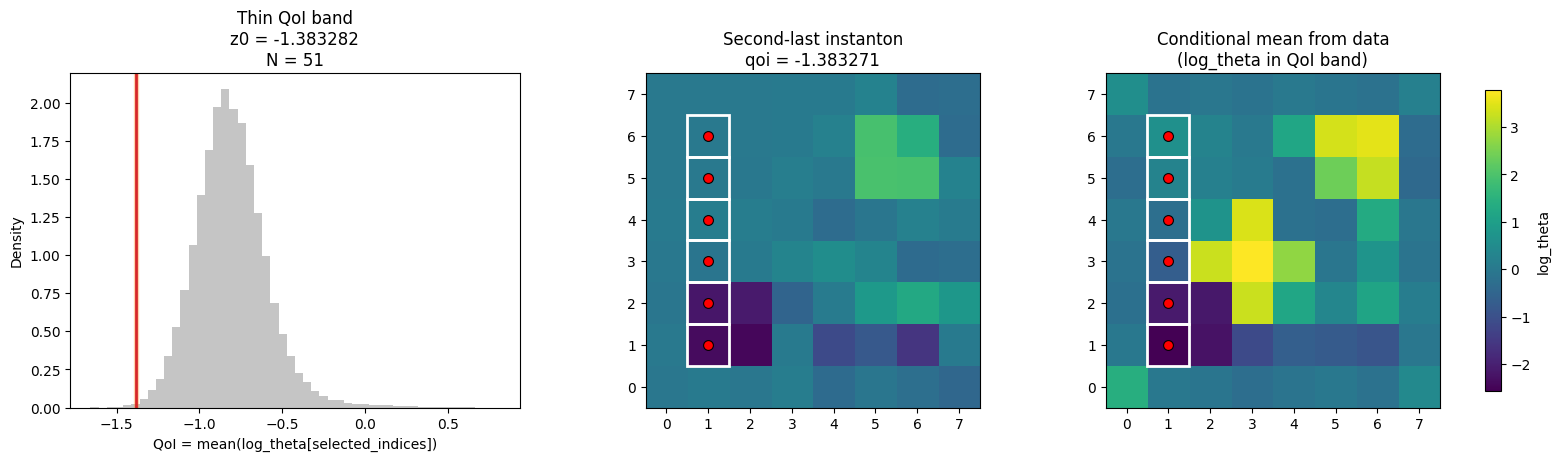

In [13]:
from matplotlib.patches import Rectangle

# Use the second-last QoI target from the existing z_grid
z0 = float(z_grid[1])

# Parse all sample fields and their QoIs in log-theta coordinates
sample_files = sorted(Path(".").glob("samples-*.txt"))
sample_log_thetas = []
sample_qois = []

for path in sample_files:
    with path.open("r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2 + solver.theta_dim:
                continue
            try:
                theta = np.asarray(parts[2:2 + solver.theta_dim], dtype=np.float64)
            except ValueError:
                continue
            if theta.size != solver.theta_dim or np.any(theta <= 0.0):
                continue

            log_theta = np.log(theta)
            qoi_val = float(np.mean(log_theta[selected_indices]))

            sample_log_thetas.append(log_theta)
            sample_qois.append(qoi_val)

sample_log_thetas = np.asarray(sample_log_thetas, dtype=np.float64)
sample_qois = np.asarray(sample_qois, dtype=np.float64)

if sample_log_thetas.size == 0:
    raise RuntimeError("No valid samples found for conditional mean plot.")

# Thin band around the target QoI, widened only if needed for enough samples
z_range = float(sample_qois.max() - sample_qois.min())
band_halfwidth =  0.01
min_samples = 20

mask = np.abs(sample_qois - z0) <= band_halfwidth
while mask.sum() < min_samples and band_halfwidth < 0.25 * z_range:
    band_halfwidth *= 1.5
    mask = np.abs(sample_qois - z0) <= band_halfwidth

if mask.sum() == 0:
    raise RuntimeError("No samples fell inside the QoI band.")

conditional_mean = sample_log_thetas[mask].mean(axis=0).reshape(solver.n_blocks, solver.n_blocks)

# Compute the instanton at the second-last QoI target
inst_res_2nd_last = instanton.searchInstantonViaAugmented(
    targetObservable=z0,
    muMin=np.log10(1.0),
    muMax=np.log10(1_000.0),
    nMu=4,
    initLbda=0.0,
    initialM=np.asarray(jax.device_get(log_theta_map), dtype=np.float64),
)

inst_field = np.asarray(jax.device_get(inst_res_2nd_last.log_theta), dtype=np.float64).reshape(
    solver.n_blocks, solver.n_blocks
)

# Helper to mark selected blocks on an axis
def mark_selected_blocks(ax, selected_pairs, edgecolor="white", pointcolor="red", lw=2.0, s=50):
    # scatter at cell centers
    xs = [j for (i, j) in selected_pairs]
    ys = [i for (i, j) in selected_pairs]
    ax.scatter(xs, ys, s=s, c=pointcolor, marker="o", edgecolors="black", linewidths=0.8, zorder=3)

    # draw rectangle around each selected cell
    for i, j in selected_pairs:
        rect = Rectangle(
            (j - 0.5, i - 0.5), 1.0, 1.0,
            fill=False, edgecolor=edgecolor, linewidth=lw, zorder=4
        )
        ax.add_patch(rect)

# Plot QoI band, instanton field, and conditional mean
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5), constrained_layout=True)

axes[0].hist(sample_qois, bins=50, density=True, alpha=0.35, color="0.35")
axes[0].axvspan(z0 - band_halfwidth, z0 + band_halfwidth, color="tab:orange", alpha=0.25)
axes[0].axvline(z0, color="tab:red", lw=2)
axes[0].set_xlabel("QoI = mean(log_theta[selected_indices])")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Thin QoI band\nz0 = {z0:.6f}\nN = {mask.sum()}")

vmin = float(min(inst_field.min(), conditional_mean.min()))
vmax = float(max(inst_field.max(), conditional_mean.max()))

im0 = axes[1].imshow(inst_field, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title(
    f"Second-last instanton\nqoi = {float(jax.device_get(inst_res_2nd_last.qoi)):.6f}"
)
axes[1].set_xticks(range(solver.n_blocks))
axes[1].set_yticks(range(solver.n_blocks))
mark_selected_blocks(axes[1], selected_pairs)

im1 = axes[2].imshow(conditional_mean, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
axes[2].set_title("Conditional mean from data\n(log_theta in QoI band)")
axes[2].set_xticks(range(solver.n_blocks))
axes[2].set_yticks(range(solver.n_blocks))
mark_selected_blocks(axes[2], selected_pairs)

fig.colorbar(im1, ax=axes[1:], shrink=0.9, label="log_theta")
plt.show()

/var/folders/3n/z_cx_y5n51b57dbgrp0vwqgc0000gn/T/ipykernel_6359/2304340693.py:47: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax_inset.grid(False, alpha=0.3, which='both')



Logdet = 148.896382
Number of eigenvalues: 63
Min eigenvalue: -1365.466957
Max eigenvalue: 0.318607
Mean eigenvalue: -56.396542
Final product ∏(1-λᵢ) = 4.622504e+64


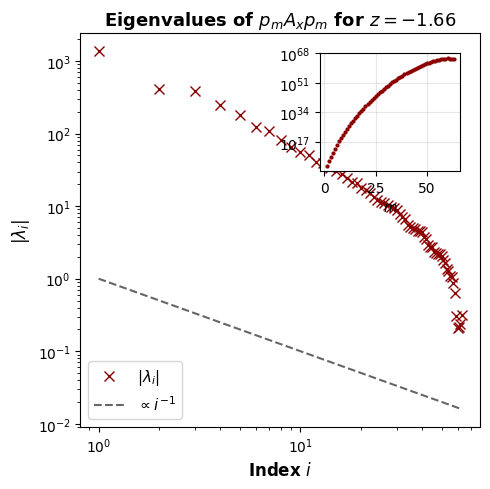

In [17]:
# --- Plot eigenvalues and logdet ---
# CHOOSE Z VALUE HERE
z_choice = z_grid[0]  # Change this to any value in z_grid or any float in the data range

# Compute instanton and eigenvalues for chosen z
res_z_choice = instanton.searchInstantonViaAugmented(
    targetObservable=float(z_choice),
    muMin=np.log10(1.0),
    muMax=np.log10(1_000.0),
    nMu=4,
    initLbda=float(inst_res.lam),
    initialM=np.asarray(jax.device_get(log_theta_map), dtype=np.float64),
)

est_z_final = instanton.exceedance_probability_estimate(
    res_z_choice,
    eps=eps_for_Zhat,
    z_hat=float(Z_hat_laplace),
    n_eigs=None,
)
evals = np.array(est_z_final.get('evals', []))

if len(evals) > 0:
    # Main plot: sorted eigenvalues
    fig, ax = plt.subplots(figsize=(5, 5))
    sorted_evals = np.sort(evals)
    ax.loglog(range(1, len(sorted_evals) + 1), np.abs(sorted_evals), 'x', 
              linewidth=1.5, markersize=7, color='darkred', label=r'$|\lambda_i|$')
    
    # Reference line for i^-1
    idx_ref = np.arange(1, len(sorted_evals) + 1)
    ax.loglog(idx_ref, 1.0 / idx_ref, 'k--', linewidth=1.5, alpha=0.6, label=r'$\propto i^{-1}$')
    
    ax.set_xlabel('Index $i$', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'$|\lambda_i|$', fontsize=12, fontweight='bold')
    ax.set_title(f'Eigenvalues of $p_m A_x p_m$ for $z={z_choice:.2f}$', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='lower left')
    #ax.grid(False, alpha=0.3, which='both')
    
    # Inset plot: cumulative product of (1 - lambda_i) - TOP RIGHT CORNER
    ax_inset = ax.inset_axes([0.6, 0.65, 0.35, 0.3])
    cum_prod = np.cumprod(np.abs(1.0 - sorted_evals))
    ax_inset.semilogy(range(1, len(cum_prod) + 1), cum_prod, 'o', 
                       linewidth=1, markersize=2, color='darkred')
    ax_inset.set_xlabel('$m$', fontsize=10)
    #ax_inset.set_ylabel(r'$\prod_{i=1}^m (1-\lambda_i)$', fontsize=10)
    ax_inset.grid(False, alpha=0.3, which='both')
    
    # Print logdet info
    logdet = est_z_final.get('logdet', None)
    if logdet is not None:
        print(f"\nLogdet = {logdet:.6f}")
        print(f"Number of eigenvalues: {len(evals)}")
        print(f"Min eigenvalue: {np.min(evals):.6f}")
        print(f"Max eigenvalue: {np.max(evals):.6f}")
        print(f"Mean eigenvalue: {np.mean(evals):.6f}")
        final_prod = np.prod(np.abs(1.0 - evals))
        print(f"Final product ∏(1-λᵢ) = {final_prod:.6e}")
else:
    print("No eigenvalues available to plot")

plt.tight_layout()
plt.show()
